In [1]:
import torch
import torchmetrics
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import ToTensor

In [2]:
toTensor = T.Compose([
	T.ToImage(), 
	# T.Resize((28, 28)),
	T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
	root='./data', 
	train=True, 
	download=True,
	transform=ToTensor()
)

test_data = torchvision.datasets.FashionMNIST(
	root='./data', 
	train=False, 
	download=True,
	transform=ToTensor()
	)

train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [0.9, 0.1])

c:\Users\user\miniconda3\envs\torch\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [3]:
print(len(train_data), len(valid_data), len(test_data))

54000 6000 10000


In [4]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [5]:
# import torchvision.transforms.v2 as T

# # x = T.ToTensor()
# # x(img)

# transforms = T.Compose([
# 	T.ToTensor(),
# 	# T.RandomRotation((-90,90)),
# 	# T.Resize((100,100))
# ])

# plt.imshow(transforms(img).squeeze(0))

In [6]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [7]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

In [8]:
X_batch, y_batch = next(iter(train_loader))

In [9]:
model = nn.Sequential(
	nn.Flatten(),
	nn.Linear(in_features=784, out_features=50),
	nn.Sigmoid(),
	nn.Linear(in_features=50, out_features=30),
	nn.Sigmoid(),
	nn.Linear(in_features=30, out_features=10),
)
criterion = nn.CrossEntropyLoss()
y_pred = model(X_batch)


In [10]:
y_pred[0]

tensor([ 0.2051, -0.0800, -0.2185, -0.5510,  0.1405,  0.4995, -0.0502, -0.0277,
        -0.0799, -0.3199], grad_fn=<SelectBackward0>)

In [11]:
y_pred[0].softmax(0)

tensor([0.1240, 0.0932, 0.0812, 0.0582, 0.1162, 0.1664, 0.0960, 0.0982, 0.0932,
        0.0733], grad_fn=<SoftmaxBackward0>)

In [12]:
np.exp(0.2394) / np.exp(y_pred[0].detach().numpy()).sum()

np.float64(0.12829817335025073)

In [13]:
X_batch[0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

Epoch: 1/20, Loss: 1.161, Train Metric: 0.614, Valid Metric: 0.776
Epoch: 2/20, Loss: 0.605, Train Metric: 0.786, Valid Metric: 0.786
Epoch: 3/20, Loss: 0.517, Train Metric: 0.819, Valid Metric: 0.82
Epoch: 4/20, Loss: 0.48, Train Metric: 0.831, Valid Metric: 0.841
Epoch: 5/20, Loss: 0.457, Train Metric: 0.839, Valid Metric: 0.848
Epoch: 6/20, Loss: 0.442, Train Metric: 0.845, Valid Metric: 0.846
Epoch: 7/20, Loss: 0.429, Train Metric: 0.85, Valid Metric: 0.859
Epoch: 8/20, Loss: 0.418, Train Metric: 0.853, Valid Metric: 0.862
Epoch: 9/20, Loss: 0.409, Train Metric: 0.856, Valid Metric: 0.86
Epoch: 10/20, Loss: 0.399, Train Metric: 0.86, Valid Metric: 0.869
Epoch: 11/20, Loss: 0.392, Train Metric: 0.862, Valid Metric: 0.86
Epoch: 12/20, Loss: 0.384, Train Metric: 0.864, Valid Metric: 0.864
Epoch: 13/20, Loss: 0.378, Train Metric: 0.866, Valid Metric: 0.87
Epoch: 14/20, Loss: 0.372, Train Metric: 0.868, Valid Metric: 0.87
Epoch: 15/20, Loss: 0.366, Train Metric: 0.871, Valid Metric: 0.8

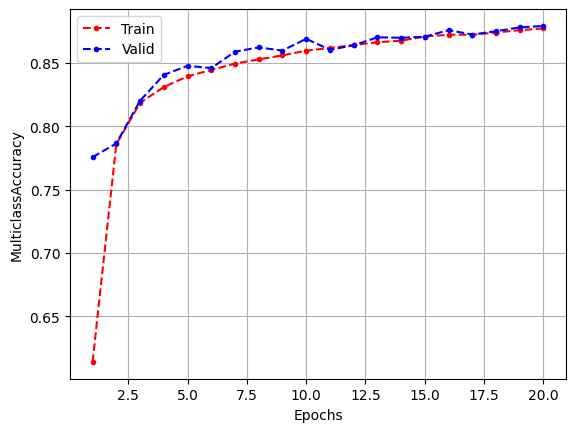

In [14]:
learning_rate = 0.01
n_epochs=20

model = nn.Sequential(
	nn.Flatten(),
	nn.Linear(in_features=1*28*28, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=10)
).to(device)
# class ImageClassifier(nn.Module):
# 	def __init__(self, n_features, n_classes):
# 		super().__init__()
# 		self.stack = nn.Sequential(
# 			nn.Flatten(),
# 			nn.Linear(in_features=n_features, out_features=30), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=n_classes)
# 		)
        
# 	def forward(self, X):
# 		y = self.stack(X)
# 		return y
# model = ImageClassifier(n_features=1*28*28, n_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

In [ ]:
metric.reset()

with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		y_pred_logits = model(X_batch)
		y_pred = y_pred_logits.argmax(dim=1)
		y_pred_cls = [test_data.classes[idx.item()] for idx in y_pred]
		metric.update(y_pred, y_batch)

In [50]:
metric.compute()

tensor(0.8624)

In [48]:
len(test_loader)

313

In [51]:
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		y_pred_logits = model(X_batch)
		y_pred = y_pred_logits.argmax(dim=1)
		y_pred_cls = [test_data.classes[idx.item()] for idx in y_pred]
		break

In [63]:
y_pred_logits.softmax(dim=1).round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1330, 0.0000, 0.0790, 0.0110,
         0.7770],
        [0.0000, 0.0000, 0.9700, 0.0000, 0.0060, 0.0000, 0.0240, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1410, 0.0000, 0.1350, 0.0040, 0.0110, 0.0000, 0.7030, 0.0000, 0.0050,
         0.0000],
        [0.0040, 0.9940, 0.0000, 0.0020, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0010, 0.0000, 0.0190, 0.0030, 0.9590, 0.0000, 0.0160, 0.0000, 0.0020,
         0.0000],
        [0.0020, 0.0000, 0.0140, 0.0000, 0.0490, 0.0000, 0.9340, 0.0000, 0.0010,
         0.0000],
        [0.0020, 0.0000, 0.0020, 0.0020, 0.0000, 0.9550, 0.0040, 0.0320, 0.0010,
         0.0010],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.9970, 0.0000,
         0.0010],
        [0

In [53]:
y_batch

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 9,
        1, 4, 6, 0, 9, 3, 8, 8])

In [55]:
y_pred_cls

['Ankle boot',
 'Pullover',
 'Trouser',
 'Trouser',
 'Shirt',
 'Trouser',
 'Coat',
 'Shirt',
 'Sandal',
 'Sneaker',
 'Coat',
 'Sandal',
 'Sneaker',
 'Dress',
 'Coat',
 'Trouser',
 'Pullover',
 'Pullover',
 'Bag',
 'T-shirt/top',
 'Pullover',
 'Sandal',
 'Sneaker',
 'Sandal',
 'Trouser',
 'Pullover',
 'Shirt',
 'T-shirt/top',
 'Ankle boot',
 'Dress',
 'Bag',
 'Bag']

In [39]:
y_pred_cls

['Ankle boot',
 'Pullover',
 'Trouser',
 'Trouser',
 'Shirt',
 'Trouser',
 'Coat',
 'Shirt',
 'Sandal',
 'Sneaker',
 'Coat',
 'Sandal',
 'Sneaker',
 'Dress',
 'Coat',
 'Trouser',
 'Pullover',
 'Pullover',
 'Bag',
 'T-shirt/top',
 'Pullover',
 'Sandal',
 'Sneaker',
 'Sandal',
 'Trouser',
 'Pullover',
 'Shirt',
 'T-shirt/top',
 'Ankle boot',
 'Dress',
 'Bag',
 'Bag']

In [65]:
torch.topk(y_pred_logits, k=5, dim=1)

torch.return_types.topk(
values=tensor([[ 6.4220,  4.6573,  4.1294,  2.1252, -1.6000],
        [14.1078, 10.4233,  9.0012,  5.5804,  2.1978],
        [15.0313,  4.8298,  3.6865,  1.3939, -0.1536],
        [13.3953,  4.3967,  2.5852,  1.1765,  0.4826],
        [ 7.1042,  5.4996,  5.4567,  2.9770,  2.2087],
        [10.1391,  4.6089,  3.8873,  1.4123,  0.7416],
        [ 7.8475,  3.8996,  3.7386,  2.0409,  1.7257],
        [ 9.0351,  6.0809,  4.8038,  3.1103,  2.1149],
        [ 5.6093,  2.2252,  0.1958, -0.4002, -0.6324],
        [ 9.4632,  2.9143,  2.2186,  1.8074, -1.5266],
        [ 8.5587,  7.0869,  6.4741,  2.8656,  1.3548],
        [ 6.2154,  2.3017,  1.1382, -0.1347, -0.3276],
        [ 5.9918,  5.1739,  3.2177, -0.3380, -0.4905],
        [ 7.7513,  2.6341,  1.2865,  0.5597, -0.2302],
        [11.1035,  7.9007,  7.6725,  7.5902,  3.6937],
        [10.8785,  4.6543,  2.6237,  2.1142,  0.3623],
        [ 7.9013,  4.3406,  3.8421,  3.6422,  1.6048],
        [ 9.1394,  8.4189,  7.601

In [64]:
y_pred_logits

tensor([[ -1.6000,  -4.6764,  -2.5969,  -3.0556,  -4.7471,   4.6573,  -2.0693,
           4.1294,   2.1252,   6.4220],
        [  5.5804,  -1.0478,  14.1078,   1.6595,   9.0012,  -4.1646,  10.4233,
         -21.8448,   2.1978, -14.6937],
        [  3.6865,  15.0313,  -0.1536,   4.8298,   1.3939,  -7.0085,  -3.7913,
          -9.1933,  -0.1765,  -7.4885],
        [  2.5852,  13.3953,   0.4826,   4.3967,   1.1765,  -6.3169,  -2.8567,
          -8.9276,  -1.8404,  -3.5956],
        [  5.4996,  -0.8466,   5.4567,   1.9220,   2.9770,  -4.7290,   7.1042,
         -10.6723,   2.2087,  -8.2470],
        [  4.6089,  10.1391,   0.7416,   3.8873,   1.4123,  -6.5566,  -0.1514,
          -8.2379,  -0.7670,  -6.7310],
        [  1.3662,  -0.2936,   3.8996,   2.0409,   7.8475,  -4.1717,   3.7386,
          -7.6424,   1.7257,  -8.3795],
        [  3.1103,  -1.3834,   4.8038,   1.2143,   6.0809,  -5.0942,   9.0351,
          -9.9266,   2.1149, -10.5901],
        [ -0.6324,  -2.0755,  -0.4002,  -0.7288,